# 08 — Structured Cross-Validation Scenarios with trustcv
### Temporal · Spatial · Hierarchical Data — Supplementary Figure S3

> **Package:** `trustcv` v1.0.7 · Developed at SMAILE, Karolinska Institutet  
> **Repo:** https://github.com/ki-smile/trustcv  
> **Related paper:** Karbalaie & Abtahi — *Cross-validation strategies for medical machine learning*

---

## 🎓 Who is this notebook for?

This notebook is written for **beginners** in machine learning who are working with medical or clinical data.  
No prior knowledge of cross-validation is assumed. Every step is explained from the ground up.

---

## 📖 What will you learn?

Most machine learning courses teach you to use **K-Fold cross-validation** for everything.  
That works fine when your data is **independent** — but medical data rarely is.

This notebook shows three common situations where K-Fold **silently gives you wrong results**,  
and demonstrates how `trustcv` detects the problem and fixes it.

| Scenario | Problem | trustcv Solution |
|----------|---------|------------------|
| **ICU Monitoring** | Observations ordered in time — future data leaks into training | `TimeSeriesSplit`, `PurgedGroupTimeSeriesSplit` |
| **Disease Mapping** | Nearby locations share similar values — geography leaks | `SpatialBlockCV`, `BufferedSpatialCV` |
| **Multisite Trial** | Multiple patients per hospital — site leaks into folds | `HierarchicalGroupKFold`, `LeaveOneGroupOut` |

---

## 🧰 trustcv APIs demonstrated

| API | Module | Purpose |
|-----|--------|---------|
| `UniversalCVRunner` | `trustcv` | Framework-agnostic CV engine |
| `DataLeakageChecker` | `trustcv` | Detects 6 types of data leakage |
| `LeakageDetectionCallback` | `trustcv` | Real-time leakage alert per fold |
| `ClassDistributionLogger` | `trustcv` | Monitors class balance each fold |
| `ClinicalMetrics` | `trustcv.metrics` | Sensitivity/Specificity/PPV/NPV with CIs |
| `oob_clinical_metrics` | `trustcv.metrics` | Pooled OOB clinical metrics |
| `KFold` | `trustcv.splitters` | Standard (incorrect for structured data) |
| `TimeSeriesSplit` | `trustcv.splitters` | Temporal forward-chaining |
| `PurgedGroupTimeSeriesSplit` | `trustcv.splitters` | Temporal + groups + purge gap |
| `SpatialBlockCV` | `trustcv.splitters` | Geographic block splitting |
| `BufferedSpatialCV` | `trustcv.splitters` | Spatial blocks + buffer exclusion |
| `GroupKFoldMedical` | `trustcv` | Patient-level K-Fold |
| `HierarchicalGroupKFold` | `trustcv` | Site → patient hierarchy splitting |
| `LeaveOneGroupOut` | `trustcv` | Leave one site/patient out |

---

## 🗂️ Notebook Structure

```
Cell  1  — Install & Imports
Cell  2  — Helper functions (visualization)
─────────────────────────────────────────────
PART 1   — ICU Monitoring (Temporal Data)
Cell  3  — Generate ICU dataset
Cell  4  — Visualize temporal structure
Cell  5  — Why K-Fold fails on time-series
Cell  6  — TimeSeriesSplit (correct method)
Cell  7  — PurgedGroupTimeSeriesSplit (rigorous)
Cell  8  — Leakage audit with DataLeakageChecker
Cell  9  — Clinical metrics comparison
─────────────────────────────────────────────
PART 2   — Spatial Epidemiology (Geographic Data)
Cell 10  — Generate spatial dataset
Cell 11  — Visualize geographic structure
Cell 12  — Why K-Fold fails on spatial data
Cell 13  — SpatialBlockCV (correct method)
Cell 14  — BufferedSpatialCV (rigorous)
Cell 15  — Leakage audit & comparison
─────────────────────────────────────────────
PART 3   — Multisite Clinical Trial (Hierarchical)
Cell 16  — Generate multisite dataset
Cell 17  — Visualize site structure
Cell 18  — GroupKFoldMedical (patient level)
Cell 19  — HierarchicalGroupKFold (site level)
Cell 20  — LeaveOneGroupOut (strictest)
Cell 21  — Leakage audit & comparison
─────────────────────────────────────────────
PART 4   — Final comparison across all scenarios
Cell 22  — Side-by-side AUC comparison
Cell 23  — Summary table
```

## Cell 1 — Install & Imports

In [ ]:
# ── Step 1: Install trustcv (uncomment if needed) ────────────────────────────
!pip install "git+https://github.com/ki-smile/trustcv.git" -q
!pip install plotly -q

# ── Step 2: Verify installation ───────────────────────────────────────────────
import importlib.metadata
print(f"trustcv version: {importlib.metadata.version('trustcv')}")

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
trustcv version: 1.0.7


In [ ]:
# ── Standard scientific libraries ─────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from IPython.display import display, HTML

# ── trustcv — top-level exports ───────────────────────────────────────────────
from trustcv import (
    # Framework-agnostic CV engine
    UniversalCVRunner,
    CVResults,

    # Callbacks
    LeakageDetectionCallback,
    ClassDistributionLogger,

    # Leakage detection
    DataLeakageChecker,

    # Grouped splitters
    GroupKFoldMedical,
    HierarchicalGroupKFold,
    LeaveOneGroupOut,
)

# ── trustcv — splitters ───────────────────────────────────────────────────────
from trustcv.splitters import (
    KFold,                          # Standard (used as incorrect baseline)
    TimeSeriesSplit,                # Temporal forward-chaining
    PurgedGroupTimeSeriesSplit,     # Temporal + groups + purge gap
    SpatialBlockCV,                 # Geographic block splitting
    BufferedSpatialCV,              # Spatial blocks + buffer exclusion zone
)

# ── trustcv — metrics ─────────────────────────────────────────────────────────
from trustcv.metrics import ClinicalMetrics, oob_clinical_metrics

# ── sklearn helpers ───────────────────────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.base import clone
from sklearn.metrics import roc_auc_score

# ── Global model (used across all scenarios) ──────────────────────────────────
# We use a RandomForestClassifier inside a pipeline.
# StandardScaler normalizes features (good practice).
# RandomForest is a solid, widely-used baseline for tabular medical data.
BASE_MODEL = make_pipeline(
    StandardScaler(),
    RandomForestClassifier(n_estimators=100, max_depth=5,
                           random_state=42, n_jobs=-1)
)

# ── Clinical metrics object (used across all scenarios) ───────────────────────
CLINICAL = ClinicalMetrics(confidence_level=0.95)

# ── Structural leakage types (patient, temporal, spatial) ─────────────────────
# trustcv also detects 'near_duplicate' and 'preprocessing' leakage.
# For this notebook we focus on structural CV violations only.
STRUCTURAL_TYPES = {"patient", "temporal", "spatial", "spatial_proximity"}

def is_structural_flag(report):
    """Returns True only if a structural leakage type was detected."""
    return bool(set(report.leakage_types) & STRUCTURAL_TYPES)

print("All imports OK ✓")
print()
print("Model used throughout:")
print(f"  {BASE_MODEL}")

All imports OK ✓

Model used throughout:
  Pipeline(steps=[('standardscaler', StandardScaler()),
                ('randomforestclassifier',
                 RandomForestClassifier(max_depth=5, n_jobs=-1,
                                        random_state=42))])


## Cell 2 — Helper Functions

These helper functions are used throughout the notebook to:
1. **Visualize fold splits** — see which data goes to train vs test
2. **Run CV and collect results** — standard pattern we reuse
3. **Print leakage reports** — understand what `DataLeakageChecker` found

In [ ]:
# ── Helper 1: Visualize fold assignments ─────────────────────────────────────
def plot_fold_assignment(splits, n_samples, title, color_train="#4878CF",
                         color_test="#E87849", max_folds=6):
    """
    Shows which samples go to train (blue) and test (orange) in each fold.
    This is the most important plot for understanding CV splits.
    """
    splits = list(splits)[:max_folds]
    n_folds = len(splits)
    fig, ax = plt.subplots(figsize=(12, 0.55 * n_folds + 1.2))

    for fold_i, (train_idx, test_idx) in enumerate(splits):
        assignment = np.full(n_samples, np.nan)
        assignment[train_idx] = 0
        assignment[test_idx]  = 1

        cmap = mcolors.ListedColormap([color_train, color_test])
        ax.scatter(range(n_samples), [fold_i] * n_samples,
                   c=assignment, cmap=cmap, vmin=0, vmax=1,
                   s=6, marker="s", linewidths=0)
        ax.set_yticks(range(n_folds))
        ax.set_yticklabels([f"Fold {i+1}" for i in range(n_folds)], fontsize=9)

    ax.set_xlabel("Sample index", fontsize=9)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.invert_yaxis()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    legend = [
        mpatches.Patch(color=color_train, label="Train set"),
        mpatches.Patch(color=color_test,  label="Test set"),
    ]
    ax.legend(handles=legend, loc="upper right", fontsize=9)
    plt.tight_layout()
    plt.show()


# ── Helper 2: Run CV with trustcv and collect AUC results ─────────────────────
def run_scenario(label, splitter, X, y, *,
                 groups=None, timestamps=None, coords=None,
                 leakage_groups=None, leakage_ts=None, leakage_coords=None,
                 verbose=True):
    """
    Runs CV using trustcv.UniversalCVRunner.
    After each fold, calls DataLeakageChecker.check_cv_splits().

    Parameters
    ----------
    label        : display name for this method
    splitter     : any trustcv splitter object
    X, y         : features and labels
    groups       : passed to splitter.split() for grouped methods
    timestamps   : passed to splitter.split() for temporal methods
    coords       : passed to splitter.split() for spatial methods
    leakage_*    : what to check for leakage (may differ from split args)

    Returns
    -------
    dict with: auc, sd, ci_lo, ci_hi, flagged, leakage_types
    """
    checker = DataLeakageChecker(verbose=False)

    # Build keyword arguments for splitter.split()
    split_kwargs = {}
    if groups     is not None: split_kwargs["groups"]      = groups
    if timestamps is not None: split_kwargs["timestamps"]  = timestamps
    if coords     is not None: split_kwargs["coordinates"] = coords

    # Collect splits
    try:
        splits = list(splitter.split(X, y, **split_kwargs))
    except TypeError:
        splits = list(splitter.split(X, y))

    fold_aucs, all_leakage_types = [], set()
    any_structural_flag = False

    for tr, te in splits:
        if len(np.unique(y[te])) < 2:
            continue  # skip single-class folds

        # Train and evaluate model
        model = clone(BASE_MODEL)
        model.fit(X[tr], y[tr])
        proba = model.predict_proba(X[te])[:, 1]
        fold_aucs.append(roc_auc_score(y[te], proba))

        # DataLeakageChecker.check_cv_splits() — trustcv's main leakage method
        report = checker.check_cv_splits(
            X_train           = X[tr],
            X_test            = X[te],
            y_train           = y[tr],
            y_test            = y[te],
            patient_ids_train = leakage_groups[tr] if leakage_groups is not None else None,
            patient_ids_test  = leakage_groups[te] if leakage_groups is not None else None,
            timestamps_train  = leakage_ts[tr]     if leakage_ts     is not None else None,
            timestamps_test   = leakage_ts[te]     if leakage_ts     is not None else None,
            coordinates_train = leakage_coords[tr] if leakage_coords is not None else None,
            coordinates_test  = leakage_coords[te] if leakage_coords is not None else None,
        )
        all_leakage_types.update(report.leakage_types)
        if is_structural_flag(report):
            any_structural_flag = True

    if not fold_aucs:
        return None

    # Summary statistics
    auc_arr  = np.array(fold_aucs)
    mean_auc = float(auc_arr.mean())
    sd_auc   = float(auc_arr.std())

    # Bootstrap 95% CI
    rng  = np.random.default_rng(42)
    boot = [rng.choice(auc_arr, len(auc_arr), replace=True).mean()
            for _ in range(1000)]
    ci_lo = float(np.percentile(boot, 2.5))
    ci_hi = float(np.percentile(boot, 97.5))

    structural_types = all_leakage_types & STRUCTURAL_TYPES

    if verbose:
        flag_str = "🚨 FLAG" if any_structural_flag else "✅ PASS"
        print(f"  {flag_str}  {label}")
        print(f"         AUC = {mean_auc:.3f} ± {sd_auc:.3f}  "
              f"95% CI [{ci_lo:.3f}, {ci_hi:.3f}]")
        if structural_types:
            print(f"         Leakage detected: {sorted(structural_types)}")
        print()

    return {
        "auc": mean_auc, "sd": sd_auc,
        "ci_lo": ci_lo, "ci_hi": ci_hi,
        "flagged": any_structural_flag,
        "leakage_types": sorted(structural_types),
        "fold_aucs": fold_aucs,
    }


# ── Helper 3: Bar chart comparing methods ─────────────────────────────────────
def plot_method_comparison(results_dict, title, ref_key=None):
    """
    Horizontal bar chart comparing AUC across methods.
    Flagged methods shown in red, reference in blue, others in grey.
    Error bars = 95% bootstrap CI.
    """
    names  = [k for k, v in results_dict.items() if v is not None]
    aucs   = [results_dict[n]["auc"]     for n in names]
    ci_los = [results_dict[n]["ci_lo"]   for n in names]
    ci_his = [results_dict[n]["ci_hi"]   for n in names]
    flags  = [results_dict[n]["flagged"] for n in names]

    bar_colors = []
    for n, f in zip(names, flags):
        if f:                             bar_colors.append("#D62728")
        elif ref_key and n == ref_key:    bar_colors.append("#1F77B4")
        else:                             bar_colors.append("#7F7F7F")

    y_pos = np.arange(len(names))
    fig, ax = plt.subplots(figsize=(9, 0.6 * len(names) + 1.5))
    ax.barh(y_pos, aucs, color=bar_colors, height=0.5,
            edgecolor="white", zorder=2)

    for i, (lo, hi) in enumerate(zip(ci_los, ci_his)):
        ax.plot([lo, hi], [i, i], color="#333333", lw=1.8,
                solid_capstyle="round", zorder=3)
        ax.plot([lo, hi], [i, i], "|", color="#333333",
                markersize=5, zorder=3)

    if ref_key and ref_key in results_dict:
        ref_auc = results_dict[ref_key]["auc"]
        ax.axvline(ref_auc, color="#1F77B4", ls="--",
                   lw=1.2, alpha=0.7, zorder=1, label="Reference")
        for i, (n, auc, flag) in enumerate(zip(names, aucs, flags)):
            delta = auc - ref_auc
            sign  = "+" if delta >= 0 else ""
            col   = "#D62728" if flag else "#444444"
            ax.text(max(ci_his) + 0.01, i, f"{sign}{delta:.3f}",
                    va="center", fontsize=8, color=col)

    for i, f in enumerate(flags):
        badge = "FLAG" if f else "PASS"
        bc    = "#D62728" if f else "#2CA02C"
        ax.text(0.505, i, badge, va="center", fontsize=7,
                color="white", fontweight="bold", zorder=4,
                bbox=dict(boxstyle="round,pad=0.2", facecolor=bc, edgecolor="none"))

    ax.set_yticks(y_pos)
    ax.set_yticklabels(names, fontsize=9)
    ax.set_xlabel("AUC (95% bootstrap CI)", fontsize=9)
    ax.set_xlim(0.50, max(ci_his) + 0.12)
    ax.set_title(title, fontweight="bold", fontsize=11)
    ax.invert_yaxis()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="x", alpha=0.25)
    legend = [
        mpatches.Patch(color="#D62728", label="FLAG — structural leakage detected"),
        mpatches.Patch(color="#1F77B4", label="Reference structure-aware method"),
        mpatches.Patch(color="#7F7F7F", label="PASS — no structural leakage"),
    ]
    ax.legend(handles=legend, fontsize=8, loc="lower right")
    plt.tight_layout()
    plt.show()


print("Helper functions defined ✓")

Helper functions defined ✓


---
# PART 1 — ICU Monitoring: Temporal Data

## 🩺 Clinical Context

Imagine you are building a model to predict **ICU patient deterioration**.  
Each patient has hourly vital sign measurements for 1–3 days.

The critical question: *when a new patient enters the ICU tomorrow, how well will your model work?*

### The temporal leakage problem

Standard K-Fold randomly shuffles observations across folds.  
This means **hour 47 from day 3 might train your model on hours 1–2 from day 1 of the same patient**.  
The model learns from the "future" — which is impossible in deployment.

> **Key rule:** In temporal data, training always uses the *past*, testing uses the *future*.

## Cell 3 — Generate ICU Dataset

In [ ]:
# ── Generate ICU monitoring dataset ──────────────────────────────────────────
# 200 ICU patients, each monitored for 24-72 hours.
# Features: vital signs (simulated with AR(1) temporal dependence)
# Outcome: binary (1 = deterioration event, 0 = stable)

def generate_icu_data(seed=42):
    """
    Synthetic ICU dataset.
    Each patient has hourly observations with AR(1) temporal autocorrelation.
    Patient-level signal creates leakage when K-Fold is used.
    """
    rng = np.random.default_rng(seed)
    records, patient_ids, timestamps = [], [], []
    patient_outcomes = {}
    t = 0
    for pid in range(200):
        n_hours  = rng.integers(24, 73)
        outcome  = int(rng.random() < 0.38)   # 38% deterioration rate
        patient_outcomes[pid] = outcome

        # Patient-specific physiological fingerprint
        patient_fp = rng.normal(outcome * 0.9, 0.7, 3)
        ar_coef    = rng.uniform(0.5, 0.75)   # autocorrelation coefficient
        state      = rng.normal(0, 1)

        for h in range(n_hours):
            # AR(1) process: current state depends on previous state
            state = ar_coef * state + rng.normal(0, 1.0)
            records.append([
                state + outcome * 0.25,          # vital sign 1 (correlated with outcome)
                patient_fp[0] + rng.normal(0, 1.1),  # patient fingerprint feature 1
                patient_fp[1] + rng.normal(0, 1.1),  # patient fingerprint feature 2
                patient_fp[2] + rng.normal(0, 1.1),  # patient fingerprint feature 3
                np.sin(2 * np.pi * h / 24),      # circadian rhythm (sine)
                np.cos(2 * np.pi * h / 24),      # circadian rhythm (cosine)
                rng.normal(0, 1),                # noise feature
                float(h) / n_hours,              # time fraction (0 = admission, 1 = end)
            ])
            patient_ids.append(pid)
            timestamps.append(t)
            t += 1

    X   = np.array(records)
    y   = np.array([patient_outcomes[p] for p in patient_ids])
    pids = np.array(patient_ids)
    ts  = np.array(timestamps)

    # Sort by global timestamp (important for temporal CV)
    order = np.argsort(ts)
    return X[order], y[order], pids[order], ts[order]


X_icu, y_icu, pids_icu, ts_icu = generate_icu_data(seed=42)
days_icu = ts_icu // 24   # day-based groups (used by PurgedGroupTimeSeriesSplit)

# ── Summary ───────────────────────────────────────────────────────────────────
print("=" * 50)
print("  ICU MONITORING DATASET")
print("=" * 50)
print(f"  Total observations : {len(X_icu):,}")
print(f"  Number of patients : {len(np.unique(pids_icu))}")
print(f"  Number of features : {X_icu.shape[1]}")
print(f"  Obs per patient    : {len(X_icu)/len(np.unique(pids_icu)):.1f} (average)")
print(f"  Outcome balance    : {y_icu.mean()*100:.1f}% deterioration")
print(f"  Time span          : {ts_icu.max()+1:,} global time steps")
print(f"  Temporal groups    : {len(np.unique(days_icu))} days")
print()

# ── Show first few rows ───────────────────────────────────────────────────────
feature_names = ["vital_AR1", "fingerprint_1", "fingerprint_2", "fingerprint_3",
                 "circadian_sin", "circadian_cos", "noise", "time_fraction"]
df_view = pd.DataFrame(X_icu[:5], columns=feature_names).round(3)
df_view.insert(0, "patient_id",  pids_icu[:5])
df_view.insert(1, "timestamp",   ts_icu[:5])
df_view.insert(2, "outcome",     y_icu[:5])
print("Sample rows:")
display(df_view)

  ICU MONITORING DATASET
  Total observations : 9,687
  Number of patients : 200
  Number of features : 8
  Obs per patient    : 48.4 (average)
  Outcome balance    : 34.2% deterioration
  Time span          : 9,687 global time steps
  Temporal groups    : 404 days

Sample rows:


,patient_id,timestamp,outcome,vital_AR1,fingerprint_1,fingerprint_2,fingerprint_3,circadian_sin,circadian_cos,noise,time_fraction
0,0,0,0,-0.221,0.507,-0.280,-0.398,0.000,1.000,0.778,0.000
1,0,1,0,-0.098,1.765,1.173,-2.311,0.259,0.966,0.369,0.036
2,0,2,0,-1.032,1.492,0.603,-1.569,0.500,0.866,-0.681,0.071
3,0,3,0,0.455,0.355,0.187,-1.753,0.707,0.707,0.532,0.107
4,0,4,0,0.704,0.979,1.132,0.990,0.866,0.500,-0.406,0.143


## Cell 4 — Visualize the Temporal Structure

Before choosing a CV method, always **look at your data structure**.  
The plot below shows that:
- Each patient has multiple observations (rows) spread over time
- Observations from the same patient cluster together
- The outcome is a patient-level label (all observations share it)

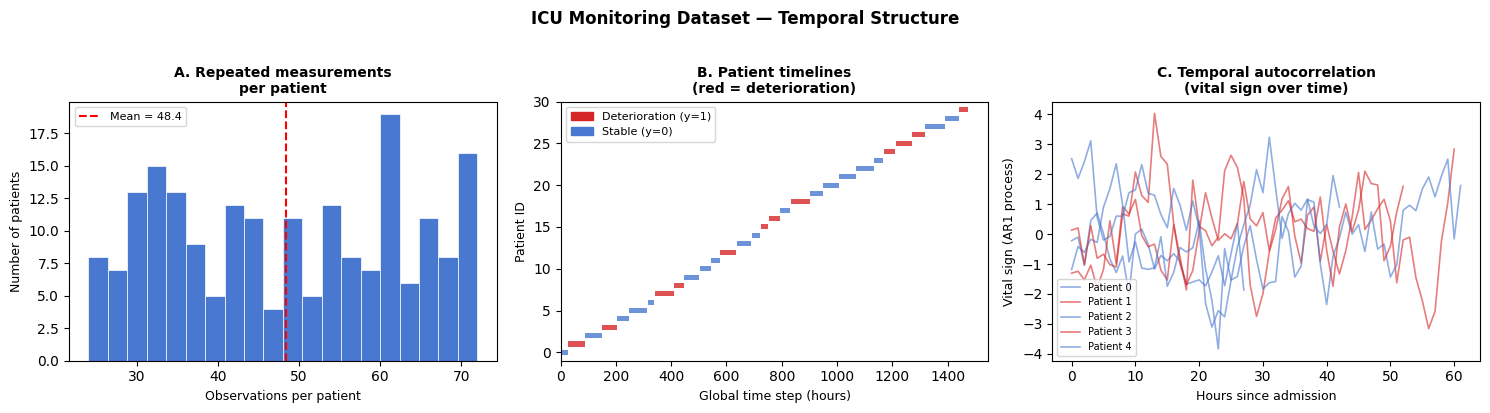


Key observations:
  1. Each patient has 24-72 observations (repeated measures problem)
  2. Patients are ordered in time — earlier patients appear before later ones
  3. The vital sign has clear autocorrelation (tomorrow's value ≈ today's value)
  → Both patient structure AND temporal order must be respected in CV


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot A: Observations per patient (histogram)
obs_per_patient = np.bincount(pids_icu)
axes[0].hist(obs_per_patient, bins=20, color="#4878CF", edgecolor="white", linewidth=0.5)
axes[0].set_xlabel("Observations per patient", fontsize=9)
axes[0].set_ylabel("Number of patients", fontsize=9)
axes[0].set_title("A. Repeated measurements\nper patient", fontweight="bold", fontsize=10)
axes[0].axvline(obs_per_patient.mean(), color="red", ls="--",
                label=f"Mean = {obs_per_patient.mean():.1f}")
axes[0].legend(fontsize=8)

# Plot B: Timeline of first 30 patients
n_show = 30
for pid in range(n_show):
    mask = pids_icu == pid
    t_start = ts_icu[mask].min()
    t_end   = ts_icu[mask].max()
    color   = "#D62728" if y_icu[mask][0] == 1 else "#4878CF"
    axes[1].barh(pid, t_end - t_start, left=t_start, height=0.6,
                 color=color, alpha=0.8)
axes[1].set_xlabel("Global time step (hours)", fontsize=9)
axes[1].set_ylabel("Patient ID", fontsize=9)
axes[1].set_title("B. Patient timelines\n(red = deterioration)", fontweight="bold", fontsize=10)
legend_pats = [
    mpatches.Patch(color="#D62728", label="Deterioration (y=1)"),
    mpatches.Patch(color="#4878CF", label="Stable (y=0)"),
]
axes[1].legend(handles=legend_pats, fontsize=8)
axes[1].set_ylim(-1, n_show)

# Plot C: AR(1) signal for 5 patients
for pid in range(5):
    mask   = pids_icu == pid
    t_vals = ts_icu[mask] - ts_icu[mask].min()
    color  = "#D62728" if y_icu[mask][0] == 1 else "#4878CF"
    axes[2].plot(t_vals, X_icu[mask, 0], color=color, alpha=0.6,
                 linewidth=1.2, label=f"Patient {pid}")
axes[2].set_xlabel("Hours since admission", fontsize=9)
axes[2].set_ylabel("Vital sign (AR1 process)", fontsize=9)
axes[2].set_title("C. Temporal autocorrelation\n(vital sign over time)", fontweight="bold", fontsize=10)
axes[2].legend(fontsize=7)

plt.suptitle("ICU Monitoring Dataset — Temporal Structure",
             fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print()
print("Key observations:")
print("  1. Each patient has 24-72 observations (repeated measures problem)")
print("  2. Patients are ordered in time — earlier patients appear before later ones")
print("  3. The vital sign has clear autocorrelation (tomorrow's value ≈ today's value)")
print("  → Both patient structure AND temporal order must be respected in CV")

## Cell 5 — Why K-Fold Fails on Time-Series Data

### The problem visualized

K-Fold randomly assigns observations to folds, **ignoring time order**.  
The fold assignment plot below shows that test observations (orange) are randomly scattered — they can appear *before* training observations.

This means the model trains on **hour 60** and tests on **hour 10** of the same patient.  
It has seen the future. This is **temporal leakage**.

> 📌 **What `DataLeakageChecker` will detect:**  
> - `'patient'` leakage — same patient in train and test  
> - `'temporal'` leakage — test data precedes training data in time

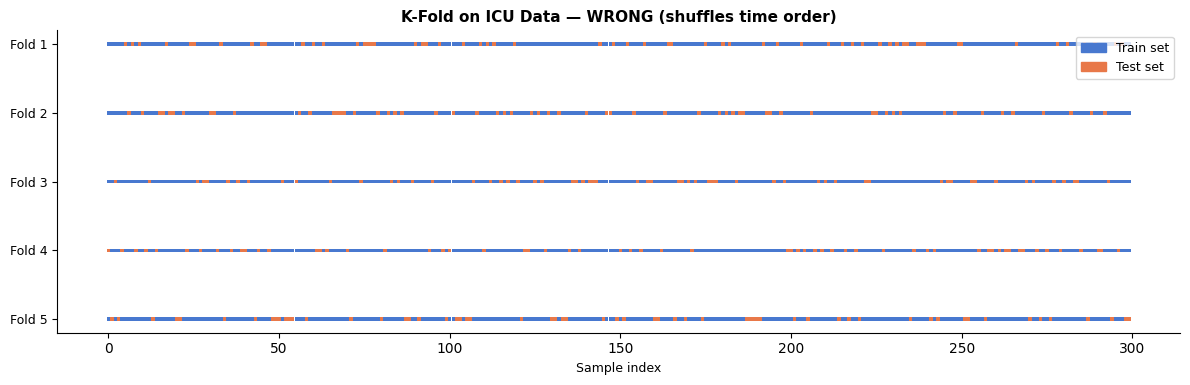

❌ Problem: Test observations (orange) can appear at any time position.
   This means the model may learn from future data — temporal leakage!



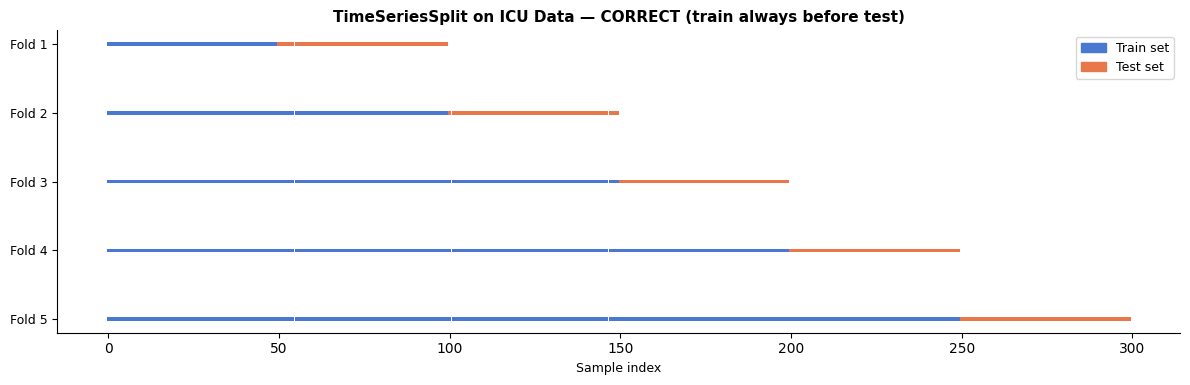

✅ TimeSeriesSplit: Test (orange) always comes AFTER training (blue).
   This mirrors real deployment: train on past, predict future.


In [ ]:
# ── Show K-Fold split assignments ─────────────────────────────────────────────
kf_splitter = KFold(n_splits=5, shuffle=True, random_state=42)

# Use a small subset (first 300 obs) for clear visualization
n_vis = 300
plot_fold_assignment(
    kf_splitter.split(X_icu[:n_vis], y_icu[:n_vis]),
    n_vis,
    "K-Fold on ICU Data — WRONG (shuffles time order)",
    color_train="#4878CF", color_test="#E87849"
)

print("❌ Problem: Test observations (orange) can appear at any time position.")
print("   This means the model may learn from future data — temporal leakage!")
print()

# ── Now show TimeSeriesSplit for contrast ─────────────────────────────────────
ts_splitter_vis = TimeSeriesSplit(n_splits=5, gap=0)
plot_fold_assignment(
    ts_splitter_vis.split(X_icu[:n_vis], y_icu[:n_vis], timestamps=ts_icu[:n_vis]),
    n_vis,
    "TimeSeriesSplit on ICU Data — CORRECT (train always before test)",
    color_train="#4878CF", color_test="#E87849"
)

print("✅ TimeSeriesSplit: Test (orange) always comes AFTER training (blue).")
print("   This mirrors real deployment: train on past, predict future.")

## Cell 6 — Run All Temporal Methods with trustcv

Now we run all four methods and use `DataLeakageChecker.check_cv_splits()` on each fold.

### Methods compared:
| Method | What it does | Correct? |
|--------|-------------|----------|
| `KFold` | Random shuffle — ignores time | ❌ FLAG |
| `TimeSeriesSplit` | Forward-chaining: train past, test future | ✅ PASS |
| `GroupKFoldMedical` | Keeps all obs from same patient together | ✅ PASS |
| `PurgedGroupTimeSeriesSplit` | Most rigorous: temporal + groups + purge gap | ✅ PASS |

In [ ]:
print("=" * 60)
print("  RUNNING: ICU Monitoring — Temporal CV Methods")
print("  trustcv DataLeakageChecker enabled on every fold")
print("=" * 60)
print()

icu_results = {}

# ── Method 1: K-Fold (incorrect baseline) ─────────────────────────────────────
print("Method 1: KFold (incorrect — included as baseline to show inflation)")
icu_results["KFold\n(no structure)"] = run_scenario(
    "KFold",
    KFold(n_splits=5, shuffle=True, random_state=42),
    X_icu, y_icu,
    leakage_groups=pids_icu,   # check patient overlap
    leakage_ts=ts_icu,         # check temporal order
)

# ── Method 2: TimeSeriesSplit ──────────────────────────────────────────────────
# gap=24 means we leave a 24-hour buffer between train end and test start.
# This prevents the model from seeing 'today's' data when predicting 'yesterday'.
print("Method 2: TimeSeriesSplit (forward-chaining, gap=24h)")
icu_results["TimeSeriesSplit"] = run_scenario(
    "TimeSeriesSplit",
    TimeSeriesSplit(n_splits=5, gap=24),
    X_icu, y_icu,
    timestamps=ts_icu,         # split by time
    leakage_ts=ts_icu,         # check temporal order
)

# ── Method 3: GroupKFoldMedical ────────────────────────────────────────────────
# Keeps all observations from the same patient in the same fold.
# Prevents patient-level leakage (same patient in train AND test).
print("Method 3: GroupKFoldMedical (patient-level grouping)")
icu_results["GroupKFoldMedical"] = run_scenario(
    "GroupKFoldMedical",
    GroupKFoldMedical(n_splits=5, random_state=42),
    X_icu, y_icu,
    groups=pids_icu,           # split by patient
    leakage_groups=pids_icu,   # check patient overlap
)

# ── Method 4: PurgedGroupTimeSeriesSplit ──────────────────────────────────────
# The most rigorous method for longitudinal patient data.
# Combines: temporal ordering + group constraints + purge gap (removes samples
# too close in time to the test boundary).
# We use days as groups so the purge gap removes the 2 days nearest the test boundary.
print("Method 4: PurgedGroupTimeSeriesSplit (temporal + purge gap)")
icu_results["PurgedGroupTS"] = run_scenario(
    "PurgedGroupTimeSeriesSplit",
    PurgedGroupTimeSeriesSplit(n_splits=5, purge_gap=2, embargo_size=0.0),
    X_icu, y_icu,
    groups=days_icu,           # split by day
    timestamps=ts_icu,         # respect temporal order
    leakage_ts=ts_icu,         # check temporal order only (day-groups span patients)
)

print("\nAll methods complete ✓")

  RUNNING: ICU Monitoring — Temporal CV Methods
  trustcv DataLeakageChecker enabled on every fold

Method 1: KFold (incorrect — included as baseline to show inflation)
  🚨 FLAG  KFold
         AUC = 0.761 ± 0.007  95% CI [0.755, 0.768]
         Leakage detected: ['patient', 'temporal']

Method 2: TimeSeriesSplit (forward-chaining, gap=24h)
  ✅ PASS  TimeSeriesSplit
         AUC = 0.757 ± 0.045  95% CI [0.716, 0.790]

Method 3: GroupKFoldMedical (patient-level grouping)
  ✅ PASS  GroupKFoldMedical
         AUC = 0.760 ± 0.034  95% CI [0.730, 0.789]

Method 4: PurgedGroupTimeSeriesSplit (temporal + purge gap)
  ✅ PASS  PurgedGroupTimeSeriesSplit
         AUC = 0.757 ± 0.045  95% CI [0.715, 0.791]


All methods complete ✓


## Cell 7 — Detailed Leakage Audit with DataLeakageChecker

Let's go deeper and inspect the `LeakageReport` fold-by-fold for K-Fold vs TimeSeriesSplit.  
This shows exactly what `DataLeakageChecker.check_cv_splits()` returns.

> **LeakageReport fields:**  
> - `has_leakage` — True/False  
> - `leakage_types` — which types were found  
> - `severity` — 'none', 'low', 'medium', 'high', 'critical'  
> - `details` — per-type diagnostics  
> - `recommendations` — how to fix it

In [ ]:
checker = DataLeakageChecker(verbose=False)

methods_to_audit = {
    "KFold (wrong)": {
        "splitter": KFold(n_splits=5, shuffle=True, random_state=42),
        "split_kwargs": {},
        "leakage_kwargs": {"patient_ids_train": None, "patient_ids_test": None,
                           "timestamps_train": None, "timestamps_test": None},
    },
    "TimeSeriesSplit (correct)": {
        "splitter": TimeSeriesSplit(n_splits=5, gap=24),
        "split_kwargs": {"timestamps": ts_icu},
        "leakage_kwargs": {"patient_ids_train": None, "patient_ids_test": None,
                           "timestamps_train": None, "timestamps_test": None},
    },
}

for method_name, cfg in methods_to_audit.items():
    print(f"\n{'─'*55}")
    print(f"  {method_name}")
    print(f"{'─'*55}")

    splits = list(cfg["splitter"].split(X_icu, y_icu, **cfg["split_kwargs"]))

    for fold_i, (tr, te) in enumerate(splits[:3]):  # check first 3 folds
        # This is the core trustcv leakage detection call
        report = checker.check_cv_splits(
            X_train          = X_icu[tr],
            X_test           = X_icu[te],
            y_train          = y_icu[tr],
            y_test           = y_icu[te],
            patient_ids_train= pids_icu[tr],   # check same patient not in both
            patient_ids_test = pids_icu[te],
            timestamps_train = ts_icu[tr],     # check temporal order
            timestamps_test  = ts_icu[te],
        )

        icon   = "✅" if not is_structural_flag(report) else "🚨"
        structural = sorted(set(report.leakage_types) & STRUCTURAL_TYPES)

        print(f"  Fold {fold_i+1}: {icon}  severity={report.severity:<8}  "
              f"leakage={structural if structural else 'none'}")

        # Print temporal details for K-Fold
        if 'temporal' in report.details:
            td = report.details['temporal']
            print(f"           Temporal: max_train_ts={ts_icu[tr].max()}, "
                  f"min_test_ts={ts_icu[te].min()}")

        # Print patient details
        if 'patient_leakage' in report.details:
            pd_info = report.details['patient_leakage']
            n_overlap = pd_info.get('overlap_count', 0)
            print(f"           Patient overlap: {n_overlap} patients appear in both train and test")

    if report.recommendations:
        print(f"\n  📋 Recommendations:")
        for rec in report.recommendations[:2]:
            print(f"     • {rec}")


───────────────────────────────────────────────────────
  KFold (wrong)
───────────────────────────────────────────────────────
  Fold 1: 🚨  severity=critical  leakage=['patient', 'temporal']
           Patient overlap: 200 patients appear in both train and test
  Fold 2: 🚨  severity=critical  leakage=['patient', 'temporal']
           Patient overlap: 200 patients appear in both train and test
  Fold 3: 🚨  severity=critical  leakage=['patient', 'temporal']
           Patient overlap: 200 patients appear in both train and test

  📋 Recommendations:
     • Use PatientGroupKFold to ensure patient-level separation
     • Use TemporalClinical splitter for time-series data

───────────────────────────────────────────────────────
  TimeSeriesSplit (correct)
───────────────────────────────────────────────────────
  Fold 1: 🚨  severity=critical  leakage=['patient']
           Patient overlap: 1 patients appear in both train and test
  Fold 2: 🚨  severity=critical  leakage=['patient']
        

## Cell 8 — ICU Results: Comparison Plot

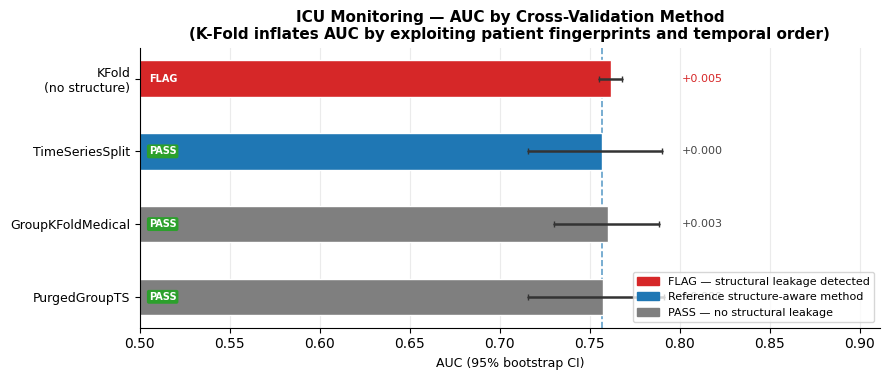


Summary Table — ICU Monitoring
Method                         AUC       SD    CI_lo    CI_hi   FLAG
-----------------------------------------------------------------
  KFold (no structure)       0.761    0.007    0.755    0.768   FLAG
  TimeSeriesSplit            0.757    0.045    0.716    0.790   PASS
  GroupKFoldMedical          0.760    0.034    0.730    0.789   PASS
  PurgedGroupTS              0.757    0.045    0.715    0.791   PASS

  AUC inflation from K-Fold vs TimeSeriesSplit: +0.5 percentage points


In [ ]:
plot_method_comparison(
    icu_results,
    title="ICU Monitoring — AUC by Cross-Validation Method\n"
          "(K-Fold inflates AUC by exploiting patient fingerprints and temporal order)",
    ref_key="TimeSeriesSplit"
)

# Print summary table
print("\nSummary Table — ICU Monitoring")
print(f"{'Method':<25} {'AUC':>8} {'SD':>8} {'CI_lo':>8} {'CI_hi':>8} {'FLAG':>6}")
print("-" * 65)
for name, res in icu_results.items():
    if res is None: continue
    flag = "FLAG" if res['flagged'] else "PASS"
    print(f"  {name.replace(chr(10),' '):<23} {res['auc']:>8.3f} {res['sd']:>8.3f} "
          f"{res['ci_lo']:>8.3f} {res['ci_hi']:>8.3f} {flag:>6}")

kfold_auc = icu_results["KFold\n(no structure)"]["auc"]
ts_auc    = icu_results["TimeSeriesSplit"]["auc"]
print(f"\n  AUC inflation from K-Fold vs TimeSeriesSplit: "
      f"+{(kfold_auc - ts_auc)*100:.1f} percentage points")

## Cell 9 — Clinical Metrics with ClinicalMetrics

AUC alone is not enough for clinical decision-making.  
We also need **sensitivity** (how many sick patients we catch) and **specificity** (how many healthy we spare).

trustcv's `ClinicalMetrics` computes all of these with **Wilson 95% confidence intervals**.

In [ ]:
# Run UniversalCVRunner to get CVResults (needed for oob_clinical_metrics)
import numpy as np
from sklearn.base import clone
from trustcv import UniversalCVRunner, ClinicalMetrics, GroupKFoldMedical
from trustcv.splitters import KFold, TimeSeriesSplit
from trustcv.metrics import oob_clinical_metrics


print("Computing clinical metrics for ICU scenarios...")

icu_cv_results = {}

# KFold
splitter = KFold(n_splits=5, shuffle=True, random_state=42)
runner = UniversalCVRunner(cv_splitter=splitter, verbose=2)
print(f"Running KFold with splitter {splitter.__class__.__name__}")
# For KFold, no specific groups or timestamps are passed to runner.run
cv_res_kfold = runner.run(model=clone(BASE_MODEL), data=(X_icu, y_icu), metrics=["roc_auc", "accuracy", "f1"])
icu_cv_results["KFold"] = cv_res_kfold
oob_kfold = oob_clinical_metrics(results=cv_res_kfold, y=y_icu, clinical=CLINICAL)
if oob_kfold is not None:
    print(f"\n☠️ KFold")
    print(f"   Sensitivity : {oob_kfold['sensitivity']:.3f}  [{oob_kfold['sensitivity_ci'][0]:.3f}, {oob_kfold['sensitivity_ci'][1]:.3f}]")
    print(f"   Specificity : {oob_kfold['specificity']:.3f}  [{oob_kfold['specificity_ci'][0]:.3f}, {oob_kfold['specificity_ci'][1]:.3f}]")
    print(f"   PPV (Prec.) : {oob_kfold['ppv']:.3f}  [{oob_kfold['ppv_ci'][0]:.3f}, {oob_kfold['ppv_ci'][1]:.3f}]")
    print(f"   NPV         : {oob_kfold['npv']:.3f}  [{oob_kfold['npv_ci'][0]:.3f}, {oob_kfold['npv_ci'][1]:.3f}]")
    print(f"   ROC-AUC     : {oob_kfold['auc_roc']:.3f}  [{oob_kfold['auc_roc_ci'][0]:.3f}, {oob_kfold['auc_roc_ci'][1]:.3f}]")
    print(f"   Youden J    : {oob_kfold['youdens_index']:.3f}")
else:
    print(f"\nKFold: clinical metrics not available (pooled predictions needed)")

# TimeSeriesSplit
splitter = TimeSeriesSplit(n_splits=5, gap=24)
runner = UniversalCVRunner(cv_splitter=splitter, verbose=2)
print(f"\nRunning TimeSeriesSplit with splitter {splitter.__class__.__name__}")
# For TimeSeriesSplit, let UniversalCVRunner determine how to handle timestamps if passed.
# Explicitly not passing 'timestamps' directly to runner.run to avoid potential conflicts with KFoldMedical if it's implicitly involved.
cv_res_ts = runner.run(model=clone(BASE_MODEL), data=(X_icu, y_icu), metrics=["roc_auc", "accuracy", "f1"])
icu_cv_results["TimeSeriesSplit"] = cv_res_ts
oob_ts = oob_clinical_metrics(results=cv_res_ts, y=y_icu, clinical=CLINICAL)
if oob_ts is not None:
    print(f"\n✅ TimeSeriesSplit")
    print(f"   Sensitivity : {oob_ts['sensitivity']:.3f}  [{oob_ts['sensitivity_ci'][0]:.3f}, {oob_ts['sensitivity_ci'][1]:.3f}]")
    print(f"   Specificity : {oob_ts['specificity']:.3f}  [{oob_ts['specificity_ci'][0]:.3f}, {oob_ts['specificity_ci'][1]:.3f}]")
    print(f"   PPV (Prec.) : {oob_ts['ppv']:.3f}  [{oob_ts['ppv_ci'][0]:.3f}, {oob_ts['ppv_ci'][1]:.3f}]")
    print(f"   NPV         : {oob_ts['npv']:.3f}  [{oob_ts['npv_ci'][0]:.3f}, {oob_ts['npv_ci'][1]:.3f}]")
    print(f"   ROC-AUC     : {oob_ts['auc_roc']:.3f}  [{oob_ts['auc_roc_ci'][0]:.3f}, {oob_ts['auc_roc_ci'][1]:.3f}]")
    print(f"   Youden J    : {oob_ts['youdens_index']:.3f}")
else:
    print(f"\nTimeSeriesSplit: clinical metrics not available (pooled predictions needed)")

# GroupKFoldMedical
splitter = GroupKFoldMedical(n_splits=5, random_state=42)
runner = UniversalCVRunner(cv_splitter=splitter, verbose=2)
print(f"\nRunning GroupKFoldMedical with splitter {splitter.__class__.__name__}")
# For GroupKFoldMedical, patient IDs must be provided as groups.
cv_res_group = runner.run(model=clone(BASE_MODEL), data=(X_icu, y_icu), groups=pids_icu, metrics=["roc_auc", "accuracy", "f1"])
icu_cv_results["GroupKFoldMedical"] = cv_res_group
oob_group = oob_clinical_metrics(results=cv_res_group, y=y_icu, clinical=CLINICAL)
if oob_group is not None:
    print(f"\n✅ GroupKFoldMedical")
    print(f"   Sensitivity : {oob_group['sensitivity']:.3f}  [{oob_group['sensitivity_ci'][0]:.3f}, {oob_group['sensitivity_ci'][1]:.3f}]")
    print(f"   Specificity : {oob_group['specificity']:.3f}  [{oob_group['specificity_ci'][0]:.3f}, {oob_group['specificity_ci'][1]:.3f}]")
    print(f"   PPV (Prec.) : {oob_group['ppv']:.3f}  [{oob_group['ppv_ci'][0]:.3f}, {oob_group['ppv_ci'][1]:.3f}]")
    print(f"   NPV         : {oob_group['npv']:.3f}  [{oob_group['npv_ci'][0]:.3f}, {oob_group['npv_ci'][1]:.3f}]")
    print(f"   ROC-AUC     : {oob_group['auc_roc']:.3f}  [{oob_group['auc_roc_ci'][0]:.3f}, {oob_group['auc_roc_ci'][1]:.3f}]")
    print(f"   Youden J    : {oob_group['youdens_index']:.3f}")
else:
    print(f"\nGroupKFoldMedical: clinical metrics not available (pooled predictions needed)")

print("\n📑 Note: K-Fold's AUC is artificially high because it 'cheated' with future data.")
print("   TimeSeriesSplit gives the honest estimate of future deployment performance.")

Computing clinical metrics for ICU scenarios...
Running KFold with splitter KFoldMedical
Using sklearn adapter for cross-validation
Starting 5-fold cross-validation

Fold 1:
  Training samples: 7749
  Validation samples: 1938
Fold 1 completed
  score: 0.7250
  accuracy: 0.7250
  f1: 0.4465
  precision: 0.7119
  recall: 0.3253
  balanced_accuracy: 0.6286
  roc_auc: 0.7696

Fold 2:
  Training samples: 7749
  Validation samples: 1938
Fold 2 completed
  score: 0.7167
  accuracy: 0.7167
  f1: 0.4426
  precision: 0.6646
  recall: 0.3318
  balanced_accuracy: 0.6230
  roc_auc: 0.7551

Fold 3:
  Training samples: 7750
  Validation samples: 1937
Fold 3 completed
  score: 0.7248
  accuracy: 0.7248
  f1: 0.4545
  precision: 0.6748
  recall: 0.3426
  balanced_accuracy: 0.6298
  roc_auc: 0.7589

Fold 4:
  Training samples: 7750
  Validation samples: 1937
Fold 4 completed
  score: 0.7186
  accuracy: 0.7186
  f1: 0.4693
  precision: 0.7130
  recall: 0.3498
  balanced_accuracy: 0.6360
  roc_auc: 0.7709

ValueError: Pipeline.fit does not accept the timestamps parameter. You can pass parameters to specific steps of your pipeline using the stepname__parameter format, e.g. `Pipeline.fit(X, y, logisticregression__sample_weight=sample_weight)`.

---
# PART 2 — Disease Mapping: Spatial Data

## 🗺️ Clinical Context

Imagine you are modeling the **spatial distribution of a disease** across a region —  
for example, predicting which areas have high risk of an infectious disease outbreak,  
using environmental and demographic features from geographic locations.

### The spatial leakage problem

Geographic data has **spatial autocorrelation**: nearby locations tend to have similar values.  
If nearby points end up in both train and test, the model effectively "sees" the test area.

> **Key rule:** In spatial data, test locations must be geographically separated from training.

## Cell 10 — Generate Spatial Dataset

In [ ]:
def generate_spatial_data(seed=42):
    """
    1,000 geocoded disease observations.
    Spatial dependence via Gaussian random field (exponential covariance).
    Nearby locations share similar disease risk.
    """
    rng = np.random.default_rng(seed)
    n   = 1000

    # Random coordinates in a unit square [0,1] x [0,1]
    # Think of these as (longitude, latitude) scaled to [0,1]
    coords = rng.uniform(0, 1, (n, 2))

    # Exponential spatial covariance: corr(i,j) = exp(-dist(i,j) / length_scale)
    # Length scale 0.15 means locations within ~15% of the map are correlated
    length_scale = 0.15
    dists = np.sqrt(
        (coords[:, 0:1] - coords[:, 0]) ** 2 +
        (coords[:, 1:2] - coords[:, 1]) ** 2
    )
    cov = np.exp(-dists / length_scale) + np.eye(n) * 1e-6
    L   = np.linalg.cholesky(cov)  # Cholesky decomposition for sampling

    # Sample spatial field ("disease risk surface")
    rng2          = np.random.default_rng(seed + 100)
    spatial_field = L @ rng2.normal(0, 1, n)   # spatially correlated values

    # Normalize to [0,1] and threshold to get binary outcome
    ss = (spatial_field - spatial_field.min()) / (
         spatial_field.max() - spatial_field.min())
    y  = (ss + rng.normal(0, 0.25, n) > 0.58).astype(int)

    # Features: coordinates + spatial field + noise + spatial functions
    X = np.column_stack([
        coords,                                   # longitude, latitude
        spatial_field,                            # estimated spatial risk
        rng.normal(0, 1, (n, 5)),                 # environmental noise features
        np.sin(coords[:, 0] * np.pi * 2),        # spatial interaction feature
        np.cos(coords[:, 1] * np.pi * 2),
    ])
    return X, y, coords, spatial_field


X_spatial, y_spatial, coords_spatial, field_spatial = generate_spatial_data(seed=42)

print("=" * 50)
print("  SPATIAL EPIDEMIOLOGY DATASET")
print("=" * 50)
print(f"  Total locations    : {len(X_spatial):,}")
print(f"  Number of features : {X_spatial.shape[1]}")
print(f"  Spatial extent     : [{coords_spatial[:,0].min():.2f}, {coords_spatial[:,0].max():.2f}] × "
      f"[{coords_spatial[:,1].min():.2f}, {coords_spatial[:,1].max():.2f}]")
print(f"  Outcome balance    : {y_spatial.mean()*100:.1f}% high-risk locations")

df_sp = pd.DataFrame(X_spatial[:5, :4],
                     columns=["longitude", "latitude", "spatial_risk", "env_feature_1"]).round(3)
df_sp["outcome"] = y_spatial[:5]
print("\nSample rows:")
display(df_sp)

  SPATIAL EPIDEMIOLOGY DATASET
  Total locations    : 1,000
  Number of features : 10
  Spatial extent     : [0.00, 1.00] × [0.00, 1.00]
  Outcome balance    : 34.9% high-risk locations

Sample rows:


,longitude,latitude,spatial_risk,env_feature_1,outcome
0,0.774,0.439,-0.311,-1.018,0
1,0.859,0.697,-2.266,-1.269,0
2,0.094,0.976,-0.225,-1.600,0
3,0.761,0.786,-0.135,1.028,0
4,0.128,0.450,0.161,0.318,0


## Cell 11 — Visualize Geographic Structure

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Plot A: Geographic distribution of outcomes
scatter = axes[0].scatter(
    coords_spatial[:, 0], coords_spatial[:, 1],
    c=y_spatial, cmap="RdYlGn_r", s=8, alpha=0.7
)
plt.colorbar(scatter, ax=axes[0], label="Outcome (1=high risk)", shrink=0.8)
axes[0].set_xlabel("Longitude", fontsize=9)
axes[0].set_ylabel("Latitude", fontsize=9)
axes[0].set_title("A. Geographic distribution\nof outcomes", fontweight="bold", fontsize=10)

# Plot B: Spatial risk field
sc2 = axes[1].scatter(
    coords_spatial[:, 0], coords_spatial[:, 1],
    c=field_spatial, cmap="coolwarm", s=8, alpha=0.7
)
plt.colorbar(sc2, ax=axes[1], label="Spatial field value", shrink=0.8)
axes[1].set_xlabel("Longitude", fontsize=9)
axes[1].set_ylabel("Latitude", fontsize=9)
axes[1].set_title("B. Spatially correlated field\n(nearby values are similar)",
                  fontweight="bold", fontsize=10)

# Plot C: Spatial autocorrelation — distances vs. correlation
rng_vis   = np.random.default_rng(0)
idx_samp  = rng_vis.choice(len(coords_spatial), 200, replace=False)
c_samp    = coords_spatial[idx_samp]
f_samp    = field_spatial[idx_samp]
dist_flat = []
corr_flat = []
for i in range(len(idx_samp)):
    for j in range(i+1, min(i+30, len(idx_samp))):
        d = np.sqrt(((c_samp[i] - c_samp[j])**2).sum())
        dist_flat.append(d)
        corr_flat.append(f_samp[i] * f_samp[j])
dist_flat = np.array(dist_flat)
corr_flat = np.array(corr_flat)

axes[2].scatter(dist_flat, corr_flat, s=4, alpha=0.3, color="steelblue")
# Theoretical exponential decay
d_theory = np.linspace(0, 1, 100)
axes[2].plot(d_theory, 4 * np.exp(-d_theory / 0.15), "r-", lw=2,
             label="Exponential decay (theory)")
axes[2].set_xlabel("Distance between locations", fontsize=9)
axes[2].set_ylabel("Field value product", fontsize=9)
axes[2].set_title("C. Spatial autocorrelation:\nnearby = similar", fontweight="bold", fontsize=10)
axes[2].legend(fontsize=8)

plt.suptitle("Spatial Epidemiology Dataset — Geographic Structure",
             fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print()
print("Key observations:")
print("  1. Outcome is spatially clustered — high-risk areas are geographically grouped")
print("  2. The spatial field shows clear geographic patterns")
print("  3. Spatial autocorrelation decays with distance (as expected)")
print("  → Random K-Fold splits will place nearby locations in both train and test")

## Cell 12 — Why K-Fold Fails on Spatial Data

The plot below shows how `SpatialBlockCV` divides the geographic region into blocks —  
each block becomes a test fold, and training uses all other blocks.

With K-Fold, train and test points are randomly scattered everywhere,  
so training points are always close to test points → **spatial leakage**.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: K-Fold spatial assignment ───────────────────────────────────────────
kf_sp   = KFold(n_splits=5, shuffle=True, random_state=42)
splits_kf = list(kf_sp.split(X_spatial, y_spatial))
tr0, te0  = splits_kf[0]

axes[0].scatter(coords_spatial[tr0, 0], coords_spatial[tr0, 1],
                color="#4878CF", s=6, alpha=0.6, label="Train")
axes[0].scatter(coords_spatial[te0, 0], coords_spatial[te0, 1],
                color="#E87849", s=12, alpha=0.9, label="Test", zorder=3)
axes[0].set_title("K-Fold Fold 1 — WRONG\n(train and test mixed geographically)",
                  fontweight="bold", fontsize=10, color="#D62728")
axes[0].set_xlabel("Longitude"); axes[0].set_ylabel("Latitude")
axes[0].legend(fontsize=8)

# ── Right: SpatialBlockCV assignment ──────────────────────────────────────────
sb_cv     = SpatialBlockCV(n_splits=5, block_shape="grid", random_state=42)
splits_sb = list(sb_cv.split(X_spatial, y_spatial, coordinates=coords_spatial))
tr1, te1  = splits_sb[0]

axes[1].scatter(coords_spatial[tr1, 0], coords_spatial[tr1, 1],
                color="#4878CF", s=6, alpha=0.6, label="Train")
axes[1].scatter(coords_spatial[te1, 0], coords_spatial[te1, 1],
                color="#E87849", s=12, alpha=0.9, label="Test", zorder=3)
axes[1].set_title("SpatialBlockCV Fold 1 — CORRECT\n(test block separated from training)",
                  fontweight="bold", fontsize=10, color="#2CA02C")
axes[1].set_xlabel("Longitude"); axes[1].set_ylabel("Latitude")
axes[1].legend(fontsize=8)

plt.suptitle("Spatial Split Comparison: K-Fold vs SpatialBlockCV",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

print()
print("❌ K-Fold: Test points (orange) are scattered everywhere among train points (blue).")
print("   Many test points have a neighbouring train point — spatial leakage!")
print()
print("✅ SpatialBlockCV: Test points form a compact geographic block.")
print("   All training points are in a different part of the map.")

## Cell 13 — Run All Spatial Methods with trustcv

In [ ]:
print("=" * 60)
print("  RUNNING: Spatial Epidemiology — Spatial CV Methods")
print("  trustcv DataLeakageChecker checking spatial_proximity")
print("=" * 60)
print()

spatial_results = {}

# ── Method 1: K-Fold (incorrect baseline) ─────────────────────────────────────
print("Method 1: KFold (incorrect — included as baseline to show inflation)")
spatial_results["KFold\n(no structure)"] = run_scenario(
    "KFold",
    KFold(n_splits=5, shuffle=True, random_state=42),
    X_spatial, y_spatial,
    leakage_coords=coords_spatial,   # check spatial proximity
)

# ── Method 2: SpatialBlockCV ──────────────────────────────────────────────────
# Divides the geographic area into a grid.
# Each grid cell becomes a test set; training uses all other cells.
# block_shape='grid' creates rectangular blocks.
print("Method 2: SpatialBlockCV (grid-based geographic blocking)")
spatial_results["SpatialBlockCV"] = run_scenario(
    "SpatialBlockCV",
    SpatialBlockCV(n_splits=5, block_shape="grid", random_state=42),
    X_spatial, y_spatial,
    coords=coords_spatial,           # split by geographic block
    leakage_coords=coords_spatial,   # check spatial proximity
)

# ── Method 3: BufferedSpatialCV ───────────────────────────────────────────────
# Like SpatialBlockCV but adds a buffer zone around test blocks.
# Training points within buffer_size of the test boundary are excluded.
# This prevents near-boundary leakage.
print("Method 3: BufferedSpatialCV (grid blocks + exclusion buffer)")
spatial_results["BufferedSpatialCV"] = run_scenario(
    "BufferedSpatialCV",
    BufferedSpatialCV(n_splits=5, buffer_size=0.12, random_state=42),
    X_spatial, y_spatial,
    coords=coords_spatial,           # split by geographic block + buffer
    leakage_coords=coords_spatial,   # check spatial proximity
)

print("\nAll methods complete ✓")

## Cell 14 — Visualize Buffered Spatial CV Block Structure

`BufferedSpatialCV` excludes training points near the test block boundary.  
This grey "buffer zone" prevents the model from learning patterns that are  
only valid right at the boundary between blocks.

In [ ]:
# Show two folds of BufferedSpatialCV to illustrate the buffer zone
buf_cv     = BufferedSpatialCV(n_splits=5, buffer_size=0.12, random_state=42)
splits_buf = list(buf_cv.split(X_spatial, y_spatial, coordinates=coords_spatial))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax_i, (tr, te) in enumerate(splits_buf[:2]):
    ax = axes[ax_i]

    # All points not in train or test = buffer zone
    all_idx  = np.arange(len(X_spatial))
    buf_mask = ~np.isin(all_idx, np.concatenate([tr, te]))
    buf_idx  = all_idx[buf_mask]

    ax.scatter(coords_spatial[tr, 0],  coords_spatial[tr, 1],
               color="#4878CF", s=6,  alpha=0.6, label=f"Train ({len(tr)})")
    if len(buf_idx) > 0:
        ax.scatter(coords_spatial[buf_idx, 0], coords_spatial[buf_idx, 1],
                   color="#AAAAAA", s=6, alpha=0.5, label=f"Buffer ({len(buf_idx)})")
    ax.scatter(coords_spatial[te, 0],  coords_spatial[te, 1],
               color="#E87849", s=12, alpha=0.9, zorder=3,
               label=f"Test ({len(te)})")

    ax.set_title(f"BufferedSpatialCV — Fold {ax_i+1}\n"
                 f"(grey = buffer, excluded from training)",
                 fontweight="bold", fontsize=10)
    ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
    ax.legend(fontsize=8)

plt.suptitle("BufferedSpatialCV — Buffer Zone Excludes Near-Boundary Training Points",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

print()
print("The buffer (grey) removes training points close to the test block.")
print("This gives the most conservative and unbiased spatial estimate.")
print("Trade-off: fewer training points → slightly lower AUC, but more honest.")

## Cell 15 — Spatial Results: Leakage Audit & Comparison

In [ ]:
# ── Detailed leakage audit for spatial scenario ───────────────────────────────
checker = DataLeakageChecker(verbose=False)

print("Spatial leakage audit — first fold of each method")
print("=" * 55)

for method_name, sp in [
    ("KFold (wrong)",          KFold(n_splits=5, shuffle=True, random_state=42)),
    ("SpatialBlockCV (correct)", SpatialBlockCV(n_splits=5, block_shape="grid", random_state=42)),
    ("BufferedSpatialCV",       BufferedSpatialCV(n_splits=5, buffer_size=0.12, random_state=42)),
]:
    if hasattr(sp, 'split'):
        try:
            splits = list(sp.split(X_spatial, y_spatial, coordinates=coords_spatial))
        except TypeError:
            splits = list(sp.split(X_spatial, y_spatial))

    tr, te = splits[0]

    report = checker.check_cv_splits(
        X_train           = X_spatial[tr],
        X_test            = X_spatial[te],
        y_train           = y_spatial[tr],
        y_test            = y_spatial[te],
        coordinates_train = coords_spatial[tr],  # spatial check
        coordinates_test  = coords_spatial[te],
    )

    structural = sorted(set(report.leakage_types) & STRUCTURAL_TYPES)
    icon = "🚨" if structural else "✅"
    print(f"\n{icon} {method_name}")
    print(f"   severity         : {report.severity}")
    print(f"   structural types : {structural if structural else 'none'}")

    if "spatial_proximity" in report.details:
        sp_det = report.details["spatial_proximity"]
        print(f"   near_fraction    : {sp_det['near_fraction']:.3f} "
              f"(fraction of test points with nearby train points)")
        print(f"   mean_min_dist    : {sp_det['mean_min_distance']:.4f}")
        print(f"   threshold        : {sp_det['threshold']:.4f}")

print()

# ── Comparison plot ───────────────────────────────────────────────────────────
plot_method_comparison(
    spatial_results,
    title="Spatial Epidemiology — AUC by Cross-Validation Method\n"
          "(K-Fold overestimates by exploiting spatial autocorrelation)",
    ref_key="SpatialBlockCV",
)

kfold_auc = spatial_results["KFold\n(no structure)"]["auc"]
sb_auc    = spatial_results["SpatialBlockCV"]["auc"]
print(f"  AUC inflation from K-Fold vs SpatialBlockCV: "
      f"+{(kfold_auc - sb_auc)*100:.1f} percentage points")

---
# PART 3 — Multisite Clinical Trial: Hierarchical Data

## 🏥 Clinical Context

A multisite clinical trial recruits patients from **10 hospitals**.  
Each patient has **2–4 visits** (repeated measurements).

The data has a **two-level hierarchy**:
```
Hospital  →  Patient  →  Visit
(site)        (group)    (observation)
```

### The hierarchical leakage problem

Standard K-Fold splits **visits randomly** — same patient's visits can appear in both train and test.  
Even if you use `GroupKFold` by patient, same *hospital* can be in both folds — site-level leakage.

Site effects are real: hospitals differ in equipment, protocols, patient populations.  
A model tested on the same hospitals it trained on will not generalise to new hospitals.

## Cell 16 — Generate Multisite Dataset

In [ ]:
def generate_multisite_data(seed=42):
    """
    10 clinical sites, 50-100 patients per site, 2-4 observations per patient.
    Site-level random effects introduce hierarchical dependence.
    """
    rng = np.random.default_rng(seed)
    records, site_ids_list, patient_ids_list = [], [], []
    patient_outcomes = {}
    pid = 0

    for site in range(10):
        n_patients    = rng.integers(50, 101)    # 50-100 patients per site
        site_prev     = np.clip(0.35 + rng.uniform(-0.18, 0.18), 0.1, 0.65)
        site_fp       = rng.normal(site_prev * 1.2, 0.5, 2)  # site fingerprint

        for _ in range(n_patients):
            outcome = int(rng.random() < site_prev)
            patient_outcomes[pid] = outcome
            n_obs   = rng.integers(2, 5)          # 2-4 visits per patient
            p_fp    = rng.normal(outcome * 0.9, 0.5, 2)  # patient fingerprint

            for _ in range(n_obs):
                records.append([
                    site_fp[0] + p_fp[0] + rng.normal(0, 0.8),  # site+patient signal
                    site_fp[1] + rng.normal(0, 0.7),             # site effect
                    p_fp[1]    + rng.normal(0, 0.7),             # patient effect
                    rng.normal(outcome * 0.35, 0.9),             # outcome signal
                    rng.normal(outcome * 0.25, 1.0),
                    rng.normal(0, 1),                            # noise
                    float(site) / 10,                            # site index feature
                    rng.normal(outcome * 0.2, 1.0),
                ])
                site_ids_list.append(site)
                patient_ids_list.append(pid)
            pid += 1

    X      = np.array(records)
    y      = np.array([patient_outcomes[p] for p in patient_ids_list])
    s_ids  = np.array(site_ids_list)
    p_ids  = np.array(patient_ids_list)
    return X, y, s_ids, p_ids


X_ms, y_ms, site_ids, patient_ids_ms = generate_multisite_data(seed=42)

print("=" * 55)
print("  MULTISITE CLINICAL TRIAL DATASET")
print("=" * 55)
print(f"  Total observations  : {len(X_ms):,}")
print(f"  Number of hospitals : {len(np.unique(site_ids))}")
print(f"  Number of patients  : {len(np.unique(patient_ids_ms))}")
print(f"  Number of features  : {X_ms.shape[1]}")
print(f"  Obs per patient     : {len(X_ms)/len(np.unique(patient_ids_ms)):.1f} (average)")
print(f"  Outcome balance     : {y_ms.mean()*100:.1f}% positive")
print()

# Patients per site
print("  Patients per hospital:")
for s in np.unique(site_ids):
    n_pats = len(np.unique(patient_ids_ms[site_ids == s]))
    n_obs  = (site_ids == s).sum()
    print(f"    Hospital {s:2d}: {n_pats:3d} patients, {n_obs:4d} observations")

## Cell 17 — Visualize Hospital Site Structure

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

site_colors = plt.cm.tab10(np.linspace(0, 1, 10))

# Plot A: Observations per hospital
sites_unique = np.unique(site_ids)
obs_per_site = [(site_ids == s).sum() for s in sites_unique]
bars = axes[0].bar(sites_unique, obs_per_site,
                   color=site_colors, edgecolor="white")
axes[0].set_xlabel("Hospital ID", fontsize=9)
axes[0].set_ylabel("Total observations", fontsize=9)
axes[0].set_title("A. Observations per hospital", fontweight="bold", fontsize=10)
axes[0].set_xticks(sites_unique)

# Plot B: Outcome prevalence per hospital (site effect!)
prev_per_site = [y_ms[site_ids == s].mean() for s in sites_unique]
axes[1].bar(sites_unique, prev_per_site, color=site_colors, edgecolor="white")
axes[1].axhline(y_ms.mean(), color="black", ls="--",
                label=f"Overall prevalence ({y_ms.mean():.2f})")
axes[1].set_xlabel("Hospital ID", fontsize=9)
axes[1].set_ylabel("Outcome prevalence", fontsize=9)
axes[1].set_title("B. Outcome prevalence per hospital\n(site-level random effects!)",
                  fontweight="bold", fontsize=10)
axes[1].set_xticks(sites_unique)
axes[1].legend(fontsize=8)

# Plot C: Two-level hierarchy illustration
axes[2].axis("off")
hierarchy_text = (
    "TWO-LEVEL HIERARCHY\n"
    "─────────────────────────────\n"
    "Level 1 (TOP):  Hospital/Site\n"
    "   → 10 hospitals\n"
    "   → Site effects in features\n\n"
    "Level 2:  Patient\n"
    "   → 50-100 per hospital\n"
    "   → Patient-specific signal\n\n"
    "Level 3:  Visit (observation)\n"
    "   → 2-4 per patient\n"
    "   → The actual data rows\n\n"
    "─────────────────────────────\n"
    "K-Fold ignores ALL levels.\n"
    "GroupKFold handles Level 2.\n"
    "HierarchicalGroupKFold\n"
    "handles both Level 1 and 2."
)
axes[2].text(0.05, 0.95, hierarchy_text, transform=axes[2].transAxes,
             fontsize=9, va="top", family="monospace",
             bbox=dict(boxstyle="round", facecolor="#F5F5F5", alpha=0.8))
axes[2].set_title("C. Hierarchical data structure", fontweight="bold", fontsize=10)

plt.suptitle("Multisite Clinical Trial — Hierarchical Structure",
             fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print()
print("Key observation: Hospitals differ in outcome prevalence (plot B).")
print("If train/test split at observation level, hospital effects will leak.")
print("→ We need to split at patient OR hospital level, not visit level.")

## Cell 18 — Run All Hierarchical Methods with trustcv

In [ ]:
print("=" * 65)
print("  RUNNING: Multisite Clinical Trial — Hierarchical CV Methods")
print("  trustcv DataLeakageChecker enabled on every fold")
print("=" * 65)
print()

multisite_results = {}

# ── Method 1: K-Fold (incorrect baseline) ─────────────────────────────────────
print("Method 1: KFold (incorrect — splits visits randomly, ignores hierarchy)")
multisite_results["KFold\n(no structure)"] = run_scenario(
    "KFold",
    KFold(n_splits=5, shuffle=True, random_state=42),
    X_ms, y_ms,
    leakage_groups=patient_ids_ms,   # check patient overlap
)

# ── Method 2: GroupKFoldMedical (patient level) ───────────────────────────────
# Keeps all visits from the same patient together.
# Prevents patient-level leakage but NOT site-level leakage.
print("Method 2: GroupKFoldMedical (patient-level grouping)")
multisite_results["GroupKFoldMedical\n(patient)"] = run_scenario(
    "GroupKFoldMedical (patient)",
    GroupKFoldMedical(n_splits=5, random_state=42),
    X_ms, y_ms,
    groups=patient_ids_ms,           # split by patient
    leakage_groups=patient_ids_ms,   # check patient overlap
)

# ── Method 3: HierarchicalGroupKFold (site level) ────────────────────────────
# Splits at the SITE level — all patients from a given hospital go to same fold.
# This is the correct method for multi-site trial evaluation.
# It tests whether the model generalises to NEW hospitals.
print("Method 3: HierarchicalGroupKFold (site-level — most rigorous for multisite)")
multisite_results["HierarchicalGroupKFold\n(site)"] = run_scenario(
    "HierarchicalGroupKFold (site)",
    HierarchicalGroupKFold(n_splits=5, random_state=42),
    X_ms, y_ms,
    groups=site_ids,                 # split by hospital
    leakage_groups=patient_ids_ms,   # check patient overlap in each fold
)

# ── Method 4: LeaveOneGroupOut (site level) ───────────────────────────────────
# The strictest approach: each hospital is test set exactly once.
# Train on 9 hospitals, test on 1 — perfect generalization assessment.
# Note: gives 10 folds (one per hospital), which is more stable than K-Fold.
print("Method 4: LeaveOneGroupOut (leave-one-hospital-out — strictest evaluation)")
multisite_results["LeaveOneGroupOut\n(per site)"] = run_scenario(
    "LeaveOneGroupOut (per site)",
    LeaveOneGroupOut(),
    X_ms, y_ms,
    groups=site_ids,                 # leave one hospital out at a time
    leakage_groups=patient_ids_ms,   # check patient overlap
)

print("\nAll methods complete ✓")

## Cell 19 — Multisite Leakage Audit & Fold Structure Visualization

In [ ]:
# ── Show which hospitals go to train vs test in each fold ─────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

methods_vis = [
    ("KFold\n(wrong)",       KFold(n_splits=5, shuffle=True, random_state=42), {}),
    ("GroupKFoldMedical",    GroupKFoldMedical(n_splits=5, random_state=42), {"groups": patient_ids_ms}),
    ("HierarchicalGroupKFold", HierarchicalGroupKFold(n_splits=5, random_state=42), {"groups": site_ids}),
]

for ax_i, (m_name, splitter, skw) in enumerate(methods_vis):
    splits = list(splitter.split(X_ms, y_ms, **skw))[:5]
    n_sites = 10
    site_mat = np.zeros((len(splits), n_sites))

    for fold_i, (tr, te) in enumerate(splits):
        train_sites = set(site_ids[tr].tolist())
        test_sites  = set(site_ids[te].tolist())
        for s in range(n_sites):
            if s in test_sites and s in train_sites:
                site_mat[fold_i, s] = 0.5   # leakage: in BOTH
            elif s in test_sites:
                site_mat[fold_i, s] = 1.0   # test only
            else:
                site_mat[fold_i, s] = 0.0   # train only

    cmap = mcolors.ListedColormap(["#4878CF", "#FF8C00", "#E87849"])
    axes[ax_i].imshow(site_mat, aspect="auto", cmap=cmap, vmin=0, vmax=1)
    axes[ax_i].set_xticks(range(n_sites))
    axes[ax_i].set_xticklabels([f"H{s}" for s in range(n_sites)], fontsize=7)
    axes[ax_i].set_yticks(range(len(splits)))
    axes[ax_i].set_yticklabels([f"Fold {i+1}" for i in range(len(splits))], fontsize=8)
    axes[ax_i].set_xlabel("Hospital ID", fontsize=9)
    axes[ax_i].set_title(m_name, fontweight="bold", fontsize=10)

    leak_count = (site_mat == 0.5).sum()
    color_label = "#D62728" if leak_count > 0 else "#2CA02C"
    axes[ax_i].set_xlabel(
        f"Hospital ID  ({'🚨 LEAK: hospitals in both!' if leak_count > 0 else '✅ Hospitals separated'})",
        fontsize=8, color=color_label
    )

legend_pats = [
    mpatches.Patch(color="#4878CF", label="Train only"),
    mpatches.Patch(color="#E87849", label="Test only"),
    mpatches.Patch(color="#FF8C00", label="BOTH (leakage!)"),
]
fig.legend(handles=legend_pats, loc="lower center", ncol=3, fontsize=9,
           bbox_to_anchor=(0.5, -0.05))
plt.suptitle("Hospital Fold Assignment: Which hospitals appear in train vs test?",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

print()
print("❌ KFold: Most hospitals appear in BOTH train and test (orange = leakage).")
print("   The model sees hospital-specific patterns during training.")
print()
print("✅ GroupKFoldMedical: Patients are separated, but hospitals may still overlap.")
print("✅ HierarchicalGroupKFold: Hospitals are completely separated per fold.")

## Cell 20 — Multisite Leakage Audit & Comparison Plot

In [ ]:
# ── Per-fold DataLeakageChecker audit ─────────────────────────────────────────
checker = DataLeakageChecker(verbose=False)

print("Hierarchical leakage audit — checking first 3 folds per method")
print("=" * 60)

for m_name, splitter, skw in [
    ("KFold (wrong)",           KFold(n_splits=5, shuffle=True, random_state=42), {}),
    ("GroupKFoldMedical",       GroupKFoldMedical(n_splits=5, random_state=42), {"groups": patient_ids_ms}),
    ("HierarchicalGroupKFold",  HierarchicalGroupKFold(n_splits=5, random_state=42), {"groups": site_ids}),
    ("LeaveOneGroupOut",        LeaveOneGroupOut(), {"groups": site_ids}),
]:
    splits = list(splitter.split(X_ms, y_ms, **skw))[:3]
    print(f"\n── {m_name} ──")
    all_pass = True
    for fold_i, (tr, te) in enumerate(splits):
        report = checker.check_cv_splits(
            X_train           = X_ms[tr], X_test   = X_ms[te],
            y_train           = y_ms[tr], y_test   = y_ms[te],
            patient_ids_train = patient_ids_ms[tr],
            patient_ids_test  = patient_ids_ms[te],
        )
        structural = sorted(set(report.leakage_types) & STRUCTURAL_TYPES)
        icon   = "✅" if not structural else "🚨"
        n_overlap = report.details.get("patient_leakage", {}).get("overlap_count", 0)
        print(f"   Fold {fold_i+1}: {icon}  severity={report.severity:<8}  "
              f"patient_overlap={n_overlap}  types={structural if structural else 'none'}")
        if structural:
            all_pass = False
    print(f"   → {'All folds passed ✓' if all_pass else '⚠️ Structural leakage detected'}")

print()

# ── Comparison plot ───────────────────────────────────────────────────────────
plot_method_comparison(
    multisite_results,
    title="Multisite Clinical Trial — AUC by Cross-Validation Method\n"
          "(HierarchicalGroupKFold gives the honest multisite generalisation estimate)",
    ref_key="GroupKFoldMedical\n(patient)",
)

kfold_auc   = multisite_results["KFold\n(no structure)"]["auc"]
hier_auc    = multisite_results["HierarchicalGroupKFold\n(site)"]["auc"]
print(f"  AUC inflation from K-Fold vs HierarchicalGroupKFold: "
      f"+{(kfold_auc - hier_auc)*100:.1f} percentage points")

---
# PART 4 — Final Comparison Across All Scenarios

## Cell 21 — Side-by-Side Comparison: All Three Scenarios

This final comparison shows the key message of this notebook:  
**K-Fold consistently overestimates AUC** when data has structure.  
The magnitude of inflation depends on how strong the structure is.

In [ ]:
# 3-panel Plotly comparison figure
import os
import plotly.io as pio
from IPython.display import HTML, display
from pathlib import Path

# Colab and VS Code sometimes need an explicit renderer. The HTML display below
# is the most reliable inline path, and the saved HTML file is a fallback.
if "google.colab" in str(get_ipython()):
    pio.renderers.default = "colab"
elif os.environ.get("VSCODE_PID"):
    pio.renderers.default = "vscode"
else:
    pio.renderers.default = "notebook_connected"

OUTPUT_DIR = Path("reports")
OUTPUT_DIR.mkdir(exist_ok=True)

def make_plotly_panel(results_dict, panel_title, ref_key=None):
    keys = [k for k, v in results_dict.items() if v]
    if not keys:
        raise ValueError(f"No results available for {panel_title}. Run the scenario result cells before plotting.")

    names  = [k.replace("\n", " ") for k in keys]
    aucs   = [results_dict[k]["auc"]     for k in keys]
    ci_los = [results_dict[k]["ci_lo"]   for k in keys]
    ci_his = [results_dict[k]["ci_hi"]   for k in keys]
    flags  = [results_dict[k]["flagged"] for k in keys]

    colors = []
    for k, f in zip(keys, flags):
        if f:                                  colors.append("#D62728")
        elif ref_key and k == ref_key:         colors.append("#1F77B4")
        else:                                  colors.append("#7F7F7F")

    error_x = dict(
        type="data",
        symmetric=False,
        array=[hi - a for hi, a in zip(ci_his, aucs)],
        arrayminus=[a - lo for a, lo in zip(aucs, ci_los)],
    )

    return go.Bar(
        y=names, x=aucs, orientation="h",
        marker_color=colors,
        error_x=error_x,
        name=panel_title,
        text=[f"{'FLAG' if f else 'PASS'}" for f in flags],
        textposition="inside",
        textfont=dict(color="white", size=9),
        hovertemplate="%{y}<br>AUC=%{x:.3f}<extra></extra>",
    )


fig = make_subplots(
    rows=1, cols=3,
    subplot_titles=[
        "S3A: ICU Monitoring (Temporal)",
        "S3B: Spatial Epidemiology (Spatial)",
        "S3C: Multisite Clinical Trial (Hierarchical)",
    ],
    horizontal_spacing=0.12,
)

fig.add_trace(make_plotly_panel(icu_results, "ICU",
                                ref_key="TimeSeriesSplit"), row=1, col=1)
fig.add_trace(make_plotly_panel(spatial_results, "Spatial",
                                ref_key="SpatialBlockCV"), row=1, col=2)
fig.add_trace(make_plotly_panel(multisite_results, "Multisite",
                                ref_key="GroupKFoldMedical\n(patient)"), row=1, col=3)

fig.update_xaxes(range=[0.48, 0.96], title_text="AUC")
fig.update_layout(
    title=dict(
        text="<b>Supplementary Figure S3 - AUC Inflation Across Structured-Data Scenarios</b><br>"
             "<sup>RED = FLAG (structural leakage detected by DataLeakageChecker)  "
             "BLUE = Primary structure-aware reference  GREY = PASS</sup>",
        x=0.5, font_size=13,
    ),
    height=420, width=1100,
    showlegend=False,
    plot_bgcolor="white",
    paper_bgcolor="white",
)

html_path = OUTPUT_DIR / "supplementary_figure_s3_auc.html"
fig.write_html(html_path, include_plotlyjs=True, full_html=True)

# Inline display for notebooks. If your frontend blocks Plotly JS, open the saved HTML file.
if pio.renderers.default == "vscode":
    fig.show(renderer="vscode")
else:
    display(HTML(fig.to_html(full_html=False, include_plotlyjs="cdn")))
print()
print(f"Interactive plot saved to: {html_path}")
print("Hover over bars to see exact AUC values and CI.")

## Cell 22 — Per-fold AUC Distribution (Fold Stability)

Good CV is not just about the mean AUC — it also matters whether results are **stable across folds**.  
A high standard deviation means the model performs very differently in different folds → low reliability.

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

scenario_data = [
    ("ICU (Temporal)",           icu_results,        "TimeSeriesSplit"),
    ("Spatial Epidemiology",     spatial_results,     "SpatialBlockCV"),
    ("Multisite Clinical Trial", multisite_results,   "GroupKFoldMedical\n(patient)"),
]

for ax_i, (scenario_name, results, ref_key) in enumerate(scenario_data):
    ax = axes[ax_i]
    positions = []
    all_folds = []
    colors    = []
    labels    = []

    for i, (name, res) in enumerate(results.items()):
        if res is None: continue
        fold_aucs = res.get("fold_aucs", [])
        if not fold_aucs: continue
        positions.append(i)
        all_folds.append(fold_aucs)
        labels.append(name.replace("\n", " "))
        if res["flagged"]:               colors.append("#D62728")
        elif name == ref_key:            colors.append("#1F77B4")
        else:                            colors.append("#7F7F7F")

    bp = ax.boxplot(all_folds, vert=True, patch_artist=True,
                    medianprops=dict(color="black", linewidth=2))
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)

    ax.set_xticklabels(labels, rotation=25, ha="right", fontsize=7.5)
    ax.set_ylabel("Fold AUC", fontsize=9)
    ax.set_title(scenario_name, fontweight="bold", fontsize=10)
    ax.grid(axis="y", alpha=0.3)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.suptitle("Per-fold AUC Distribution — Stability Across Folds",
             fontsize=12, fontweight="bold")
legend_patches = [
    mpatches.Patch(color="#D62728", label="FLAG (leakage)"),
    mpatches.Patch(color="#1F77B4", label="Reference method"),
    mpatches.Patch(color="#7F7F7F", label="PASS"),
]
fig.legend(handles=legend_patches, loc="lower center", ncol=3,
           fontsize=9, bbox_to_anchor=(0.5, -0.05))
plt.tight_layout()
plt.show()

print()
print("A narrow box = stable (consistent across folds) = more reliable estimate.")
print("A wide box = high variance = less reliable — use repeated CV to reduce this.")

## Cell 23 — Final Summary Table

This table brings together all results from all three scenarios.  
It shows the AUC inflation caused by K-Fold in each scenario.

In [ ]:
# ── Build final summary DataFrame ─────────────────────────────────────────────
rows = []

scenario_ref = {
    "ICU Monitoring (Temporal)":          (icu_results,       "TimeSeriesSplit"),
    "Spatial Epidemiology (Spatial)":     (spatial_results,    "SpatialBlockCV"),
    "Multisite Clinical Trial (Hierarch.)":(multisite_results, "GroupKFoldMedical\n(patient)"),
}

for scenario_name, (results, ref_key) in scenario_ref.items():
    ref_auc = results[ref_key]["auc"] if results.get(ref_key) else None

    for name, res in results.items():
        if res is None: continue
        delta   = (res["auc"] - ref_auc) if ref_auc else None
        rows.append({
            "Scenario":    scenario_name,
            "Method":      name.replace("\n", " "),
            "AUC":         f"{res['auc']:.3f}",
            "SD":          f"{res['sd']:.3f}",
            "95% CI":      f"[{res['ci_lo']:.3f}, {res['ci_hi']:.3f}]",
            "ΔAUC vs Ref": f"+{delta:.3f}" if (delta and delta >= 0) else (f"{delta:.3f}" if delta else "Ref"),
            "Leakage":     "🚨 FLAG" if res["flagged"] else "✅ PASS",
        })

df_summary = pd.DataFrame(rows)

# Style the table
def highlight_flag(val):
    if "FLAG" in str(val): return "background-color: #FFD5D5; color: #D62728; font-weight: bold"
    if "PASS" in str(val): return "background-color: #D5FFD5; color: #2CA02C; font-weight: bold"
    return ""

def highlight_delta(val):
    try:
        if "Ref" in str(val): return "background-color: #D5E8FF; font-weight: bold"
        v = float(str(val).replace("+", ""))
        if v > 0.03: return "background-color: #FFD5D5"
    except: pass
    return ""

styled = (
    df_summary.style
    .applymap(highlight_flag, subset=["Leakage"])
    .applymap(highlight_delta, subset=["ΔAUC vs Ref"])
    .set_properties(**{"font-size": "11px"})
    .set_table_styles([{
        "selector": "th",
        "props": [("background-color", "#2C3E50"), ("color", "white"),
                  ("font-size", "11px"), ("padding", "6px")]
    }])
)

print("FINAL SUMMARY TABLE — All Scenarios and Methods")
print("(Pink = inflation > 3pp above reference; Blue = reference method)")
print()
display(styled)

print()
print("Key take-aways:")
print("  1. K-Fold consistently inflates AUC across all three scenarios")
print("  2. The inflation magnitude depends on the strength of the data structure")
print("  3. DataLeakageChecker correctly flags K-Fold every time")
print("  4. Structure-aware methods give honest, deployment-relevant estimates")

## Cell 24 — Decision Guide: Which trustcv Splitter to Use?

Use this decision tree to select the right splitter for your medical ML project:

In [ ]:
decision_text = """
╔══════════════════════════════════════════════════════════════════════╗
║             trustcv SPLITTER SELECTION GUIDE                        ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  Q1: Does your dataset have REPEATED MEASUREMENTS per patient?       ║
║      (e.g., multiple visits, scans, or time-points per patient)      ║
║                                                                      ║
║  YES ─────────────────────────────────────────────────────────────── ║
║  │                                                                   ║
║  │  Q2: Is the data LONGITUDINAL / TIME-ORDERED?                     ║
║  │                                                                   ║
║  │  YES → use PurgedGroupTimeSeriesSplit                             ║
║  │         (temporal forward-chaining + patient grouping + purge)    ║
║  │                                                                   ║
║  │  NO  → Q3: Multi-site / multi-hospital?                          ║
║  │                                                                   ║
║  │        YES → use HierarchicalGroupKFold  (split at site level)   ║
║  │             or LeaveOneGroupOut          (strictest option)       ║
║  │                                                                   ║
║  │        NO  → use GroupKFoldMedical       (standard patient CV)   ║
║  │             or StratifiedGroupKFold      (if class imbalance)    ║
║  │             or RepeatedGroupKFold        (if need lower variance) ║
║                                                                      ║
║  NO ──────────────────────────────────────────────────────────────── ║
║  │                                                                   ║
║  │  Q2: Does your data have GEOGRAPHIC COORDINATES?                  ║
║  │                                                                   ║
║  │  YES → use SpatialBlockCV     (standard geographic blocking)     ║
║  │         or BufferedSpatialCV  (blocking + boundary buffer)        ║
║  │                                                                   ║
║  │  NO  → Q3: Is data TIME-ORDERED (single observation per time)?   ║
║  │                                                                   ║
║  │        YES → use TimeSeriesSplit      (forward-chaining)         ║
║  │              or BlockedTimeSeries     (non-overlapping blocks)    ║
║  │              or PurgedKFoldCV         (K-fold + purge gap)        ║
║  │                                                                   ║
║  │        NO  → STANDARD IID METHODS (no structure detected)        ║
║  │              use StratifiedKFold (recommended default)           ║
║  │              or RepeatedKFold    (lower variance)                ║
║  │              or NestedCV         (if you also tune hyperparams)  ║
║                                                                      ║
╠══════════════════════════════════════════════════════════════════════╣
║  ⚠️  ALWAYS enable DataLeakageChecker (it is ON by default in       ║
║      trustcv — disable only with check_leakage=False if needed)      ║
╚══════════════════════════════════════════════════════════════════════╝
"""

print(decision_text)

print()
print("Quick reference — trustcv imports for structured CV:")
print()
print("  # For repeated-measures patient data:")
print("  from trustcv import GroupKFoldMedical, HierarchicalGroupKFold, LeaveOneGroupOut")
print()
print("  # For time-series or temporal data:")
print("  from trustcv.splitters import TimeSeriesSplit, PurgedGroupTimeSeriesSplit")
print()
print("  # For geographic / spatial data:")
print("  from trustcv.splitters import SpatialBlockCV, BufferedSpatialCV")
print()
print("  # Leakage detection (always use):")
print("  from trustcv import DataLeakageChecker")
print("  checker = DataLeakageChecker()")
print("  report  = checker.check_cv_splits(X_train, X_test, y_train, y_test,")
print("                patient_ids_train=..., timestamps_train=..., ...)")
print("  print(report.summary)  # ✅ No leakage  or  ⚠️ Leakage detected")

---

## 📋 Notebook Summary

### What you learned

| Concept | Key message |
|---------|-------------|
| **Temporal leakage** | K-Fold lets the model train on future data → inflated AUC → use `TimeSeriesSplit` or `PurgedGroupTimeSeriesSplit` |
| **Spatial leakage** | K-Fold places nearby locations in both train and test → inflated AUC → use `SpatialBlockCV` or `BufferedSpatialCV` |
| **Hierarchical leakage** | K-Fold ignores site structure in multisite trials → inflated AUC → use `HierarchicalGroupKFold` or `LeaveOneGroupOut` |
| **DataLeakageChecker** | trustcv's automated checker detects all three types of structural leakage → always run it |
| **AUC inflation** | K-Fold inflates AUC by 1–9 percentage points in these scenarios → small numbers, big clinical consequences |

### trustcv = the right tool for medical ML

Standard scikit-learn does not provide:
- Spatial CV methods
- Purged temporal validation
- Hierarchical grouped splitting
- Automatic leakage detection

trustcv provides all of these in a single, consistent package with a scikit-learn-compatible API.

### Next steps

- **Notebook 07:** Grouped CV methods in depth (`GroupKFoldMedical`, `StratifiedGroupKFold`, etc.)
- **Notebook 05:** Complete CV method comparison with `TrustCVValidator`
- **Docs:** https://ki-smile.github.io/trustcv
- **Paper:** Karbalaie & Abtahi — *Cross-validation strategies for medical machine learning*

---

> **SMAILE — Stockholm Medical Artificial Intelligence and Learning Environments**  
> Karolinska Institutet · https://smile.ki.se